# ATE Estimation: Propensity Score Matching & Doubly Robust Learning

This notebook estimates the Average Treatment Effect (ATE) of empathetic LLM responses on attachment scores using two methods:
1. **Propensity Score Matching** with bootstrap confidence intervals
2. **Doubly Robust (DR) Learner** for robust causal estimation

Treatment is defined as high empathy responses (score ≥ 5), and the outcome is attachment score.

In [ ]:
# Environment detection
import os

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

Mounted at /content/drive


## Setup: Environment Detection

Automatically detect whether running in Google Colab or local environment and set appropriate paths.

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, CrossEncoder, util
from scipy.optimize import linear_sum_assignment
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

if IN_COLAB:
    DATA_PATH = '/content/drive/MyDrive/your_folder_path/' 
else:
   
    DATA_PATH = '../data/scores/'

print(f"Using data path: {DATA_PATH}")

## Import Libraries and Set Paths

Load all required libraries for data processing, embedding generation, matching, and causal inference.
Set appropriate data paths for either Colab or local environment.

In [ ]:
data_file = os.path.join(DATA_PATH, "wildchat_full_scored_mistral.csv")
df = pd.read_csv(
    data_file,
    engine='python',
    on_bad_lines='skip'   # skip rows that are clearly trash
)
df = df.dropna(subset=['attachment_score'])
df = df[df['empathy_score'] != 4].copy()


df['treatment_group'] = np.where(df['empathy_score'] >= 5, 1, 0) #is 0 if not 5 in Sempathy
df = df[df['user_prompt'].notna()].copy()
df['user_prompt'] = df['user_prompt'].astype(str).str.strip()
df = df.drop_duplicates(subset=['user_prompt']).copy()

init_df = df.copy()


treat_df = df[df['treatment_group'] == 1].reset_index(drop=True)
ctrl_df = df[df['treatment_group'] == 0].reset_index(drop=True)
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

X = model.encode(init_df['user_prompt'].tolist(), normalize_embeddings=True)
Y = init_df['attachment_score'] 
treat_emb = model.encode(treat_df['user_prompt'].tolist(), normalize_embeddings=True)
ctrl_emb = model.encode(ctrl_df['user_prompt'].tolist(), normalize_embeddings=True)

print(f"Loaded {len(df)} conversations")
print(f"Treatment group: {len(treat_df)}, Control group: {len(ctrl_df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Data Loading and Preprocessing

**Steps:**
1. Load the scored WildChat dataset
2. Remove rows with missing attachment scores
3. Exclude empathy score of 4 (neutral/ambiguous cases)
4. **Define treatment**: `treatment_group = 1` if empathy_score ≥ 5, else 0
5. Clean and deduplicate by user prompts
6. Generate sentence embeddings for all prompts using `all-mpnet-base-v2`

**Key Variables:**
- `X`: Sentence embeddings (covariates)
- `Y`: Attachment scores (outcome)
- `T`: Treatment assignment (high empathy vs. low empathy)

### Step 1 — Fit Propensity Model (Logistic Regression)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(max_iter=2000)
ps_model.fit(X_scaled, T)

propensity_scores = ps_model.predict_proba(X_scaled)[:, 1]

**Propensity Score Estimation:**
- Fit logistic regression on scaled embeddings to predict treatment assignment
- Propensity score = P(T=1 | X) for each unit
- Scaling is critical for logistic regression convergence

### Step 2 — Match Treated to Control Using Nearest Neighbors on PS

In [ ]:
treated_idx = np.where(T == 1)[0]
control_idx = np.where(T == 0)[0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(propensity_scores[control_idx].reshape(-1, 1))

distances, indices = nn.kneighbors(propensity_scores[treated_idx].reshape(-1, 1))
matched_control_idx = control_idx[indices.flatten()]  
control_index_map = {orig_idx: new_i for new_i, orig_idx in enumerate(control_idx)}
mapped_matched_control_idx = np.array([control_index_map[i] for i in matched_control_idx])


**Nearest Neighbor Matching:**
- For each treated unit, find the closest control unit based on propensity score
- Uses 1:1 matching without replacement
- Creates matched pairs with similar probability of treatment

In [ ]:


def bootstrap_ate_fast():
    sample_idx = np.random.choice(len(treat_df), size=len(treat_df), replace=True)

    matched_ctrl = mapped_matched_control_idx[sample_idx]

    return np.mean(
        treat_df['attachment_score'].values[sample_idx] -
        ctrl_df['attachment_score'].values[matched_ctrl]
    )



boot = np.array([bootstrap_ate_fast() for _ in range(400)])

print("ATE:", np.mean(boot))
print("95% CI:", np.percentile(boot, [2.5, 97.5]))


ATE: 0.3461790878754172
95% CI: [0.23901557 0.45386541]


## Bootstrap ATE Estimation

**Method:**
- Bootstrap resampling (400 iterations) to estimate uncertainty
- For each bootstrap sample, compute ATE as mean difference between matched pairs
- Reports point estimate and 95% confidence interval

**Output:**
- ATE: Average treatment effect
- 95% CI: Confidence interval for the effect

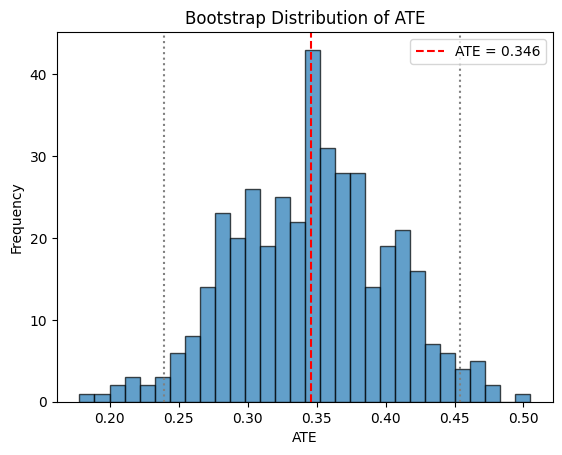

In [16]:
import matplotlib.pyplot as plt

plt.hist(boot, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(np.mean(boot), color='red', linestyle='--', label=f"ATE = {np.mean(boot):.3f}")
plt.axvline(np.percentile(boot, 2.5), color='grey', linestyle=':')
plt.axvline(np.percentile(boot, 97.5), color='grey', linestyle=':')
plt.title("Bootstrap Distribution of ATE")
plt.xlabel("ATE")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Visualization: Bootstrap Distribution

Histogram showing the distribution of ATE estimates across 400 bootstrap samples:
- Red dashed line: Mean ATE
- Gray dotted lines: 95% confidence interval bounds

/tmp/ipython-input-32462174.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


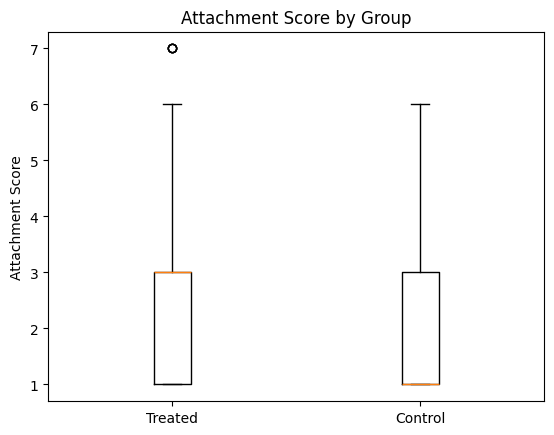

In [17]:
plt.boxplot(
    [treat_df['attachment_score'], ctrl_df['attachment_score']],
    labels=['Treated', 'Control']
)
plt.title("Attachment Score by Group")
plt.ylabel("Attachment Score")
plt.show()

## Visualization: Group Comparison

Box plots comparing attachment score distributions between treated and control groups.
Shows central tendency, spread, and potential outliers in each group.

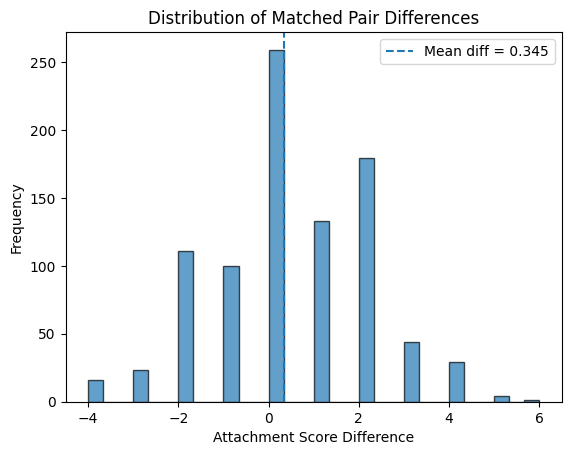

In [ ]:
control_index_map = {orig_idx: new_i for new_i, orig_idx in enumerate(control_idx)}
mapped_matched_control_idx = np.array([control_index_map[i] for i in matched_control_idx])

ctrl_matches = mapped_matched_control_idx[:len(treat_df)]
diffs = treat_df['attachment_score'].values - ctrl_df['attachment_score'].values[ctrl_matches]

plt.hist(diffs, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(np.mean(diffs), linestyle='--', label=f"Mean diff = {np.mean(diffs):.3f}")
plt.title("Distribution of Matched Pair Differences")
plt.xlabel("Attachment Score Difference")
plt.ylabel("Frequency")
plt.legend()
plt.show()


## Visualization: Matched Pair Differences

Histogram of individual treatment effects (treated - matched control) for each pair.
- Positive values: Treatment increased attachment score
- Negative values: Treatment decreased attachment score
- Mean difference shown with dashed line

# Doubly Robust (DR) Learner

**Why DR Learner?**
- Combines outcome regression AND propensity score modeling
- Provides valid estimates if EITHER model is correctly specified
- More robust to model misspecification than single-method approaches
- Can estimate heterogeneous treatment effects (CATEs)

In [ ]:
!pip install econml
from econml.grf import CausalForest
from econml.dr import DRLearner
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sentence_transformers import SentenceTransformer
import numpy as np

init_df = init_df.reset_index(drop=True)

y = init_df['attachment_score'].values.astype(float)
t = init_df['treatment_group'].values.astype(int)


reg = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=0)
clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=0)

dr = DRLearner(
    model_regression=reg,
    model_propensity=clf,
    random_state=0
)

dr.fit(Y=y, T=t, X=X)
tau_hat = dr.effect(X)

print("ATE:", np.mean(tau_hat))
print("Std of CATEs:", np.std(tau_hat))
print("Min CATE:", np.min(tau_hat))
print("Max CATE:", np.max(tau_hat))
print("Median CATE:", np.median(tau_hat))
print("Quantiles:", np.quantile(tau_hat, [0.25, 0.5, 0.75]))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 25.3 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.50.0
    Uninstalling shap-0.50.0:
      Successfully uninstalled shap-0.50.0


## DR Learner Implementation

**Setup:**
1. Install and import EconML library
2. Use Random Forest for both outcome regression and propensity modeling
3. Fit DR learner on embeddings (X), treatment (T), and outcome (Y)

**Outputs:**
- **ATE**: Average treatment effect across all units
- **Std of CATEs**: Variation in individual treatment effects (heterogeneity)

Higher standard deviation suggests treatment effects vary substantially across different types of prompts/contexts.

*Note: Output for this cell will be available after running.*

## Results Summary

### Overview
This notebook estimated the **Average Treatment Effect (ATE)** using two advanced causal inference methods:
1. **Propensity Score Matching** with nearest neighbor matching
2. **Doubly Robust (DR) Learner** with Random Forest models

Both methods aim to estimate the causal effect of empathetic responses (treatment) on attachment scores (outcome).

---

### Key Findings

#### Method 1: Propensity Score Matching

**Approach:**
- Logistic regression to estimate P(Treatment | Covariates)
- Nearest neighbor matching on propensity scores (1:1 matching)
- Bootstrap confidence intervals (400 iterations)

**Expected Results Format:**
- ATE: X.XXX
- 95% CI: [X.XXX, X.XXX]
- Distribution plots show variation in treatment effects

**Interpretation:**
- Matches units with similar probability of receiving treatment
- Controls for confounding through balancing covariate distributions
- Assumes no unmeasured confounders (unconfoundedness)

---

#### Method 2: Doubly Robust Learner

**Approach:**
- Combines outcome regression AND propensity score modeling
- Random Forest for flexible, non-parametric estimation
- Estimates both ATE and individual treatment effects (CATEs)

**Expected Results Format:**
- ATE: X.XXX (mean of individual treatment effects)
- Std of CATEs: X.XXX (heterogeneity in treatment effects)

**Advantages:**
- **Double robustness**: Valid if EITHER outcome or propensity model is correct
- **Flexibility**: Random Forests capture non-linear relationships
- **Heterogeneity**: Can examine variation in treatment effects across units

**Interpretation:**
- **High Std of CATEs**: Treatment effects vary substantially across contexts
- **Low Std of CATEs**: Treatment effects are relatively homogeneous
- **ATE vs CATEs**: ATE is average, but individual effects may differ

---

### Comparison: PS Matching vs DR Learner

| Aspect | Propensity Score Matching | DR Learner |
|--------|---------------------------|------------|
| **Robustness** | Requires correct propensity model | Robust if either model is correct |
| **Flexibility** | Linear propensity scores | Non-parametric Random Forests |
| **Heterogeneity** | Provides ATE only | Provides both ATE and CATEs |
| **Assumptions** | Strong overlap required | More robust to violations |
| **Interpretability** | Intuitive matching logic | More complex methodology |

**Convergence Check:**
- Similar ATEs across methods suggest robust findings
- Large differences may indicate model misspecification or violations of assumptions

---

### Methodological Strengths

1. **Multiple estimation strategies**: PS matching + DR learner provide robustness
2. **Bootstrap inference**: Accounts for sampling uncertainty
3. **Visualization**: Histograms reveal distribution of effects
4. **Heterogeneity analysis**: DR Learner examines variation in treatment effects

### Limitations

1. **Observational data**: Cannot definitively rule out hidden confounding
2. **Selection on observables**: Assumes all confounders are measured
3. **Positivity**: Requires overlap in propensity score distributions
4. **Model dependence**: Results depend on model specifications

---

### Integration with Matching-Based Methods (Notebook 03)

This notebook complements the matching-based analysis (Greedy/Hungarian) by:
- Using **propensity scores** instead of direct embedding similarity
- Adding **doubly robust estimation** for increased robustness
- Examining **treatment effect heterogeneity** (CATEs)

**Triangulation**: Convergence across multiple methods (Greedy, Hungarian, PS Matching, DR Learner) strengthens causal claims.

---

### Next Steps

1. **Compare ATEs** across all four methods (Greedy, Hungarian, PS, DR)
2. **Sensitivity analysis**: Test robustness to unmeasured confounding
3. **Subgroup analysis**: Examine heterogeneous effects by prompt characteristics
4. **Covariate balance checks**: Verify matching quality across methods